<a href="https://colab.research.google.com/github/ligi-data-analytics/Real-time-financial-fraud-detection/blob/main/01_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Financial Fraud Detection
# 01 - Exploratory Data Analysis (EDA)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

print(os.listdir('/content/drive/MyDrive'))

['Colab Notebooks', 'Getting started.pdf', 'Study Material DM  Data Analytics .gsheet']


In [ ]:
import os

print(os.listdir('/content/drive/MyDrive/Financial_Fraud_Detection'))

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Financial_Fraud_Detection'

In [ ]:
import os

print(os.listdir('/content/drive/MyDrive'))

['Colab Notebooks', 'Getting started.pdf', 'Study Material DM  Data Analytics .gsheet', 'financial_fraud_detection_dataset.csv']


In [ ]:
# Load Financial Fraud Detection Dataset

file_path = '/content/drive/MyDrive/financial_fraud_detection_dataset.csv'

df = pd.read_csv(file_path)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (5000000, 18)


In [ ]:
# Dataset Overview

print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

print("\nColumn Names:")
print(df.columns.tolist())

Number of Rows: 5000000
Number of Columns: 18

Column Names:
['transaction_id', 'timestamp', 'sender_account', 'receiver_account', 'amount', 'transaction_type', 'merchant_category', 'location', 'device_used', 'is_fraud', 'fraud_type', 'time_since_last_transaction', 'spending_deviation_score', 'velocity_score', 'geo_anomaly_score', 'payment_channel', 'ip_address', 'device_hash']


In [ ]:
# Data Types and Memory Usage

print("Data Types:")
print(df.dtypes)

print("\nMemory Usage:")
df.info(memory_usage="deep")

Data Types:
transaction_id                  object
timestamp                       object
sender_account                  object
receiver_account                object
amount                         float64
transaction_type                object
merchant_category               object
location                        object
device_used                     object
is_fraud                          bool
fraud_type                      object
time_since_last_transaction    float64
spending_deviation_score       float64
velocity_score                   int64
geo_anomaly_score              float64
payment_channel                 object
ip_address                      object
device_hash                     object
dtype: object

Memory Usage:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000000 entries, 0 to 4999999
Data columns (total 18 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   transaction_id               object 
 1   timestamp    

In [ ]:
# Missing Value Analysis

missing_values = df.isnull().sum()

missing_percentage = (missing_values / len(df)) * 100

missing_summary = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing Percentage': missing_percentage
})

missing_summary = missing_summary[missing_summary['Missing Count'] > 0]

print(missing_summary.sort_values(by='Missing Count', ascending=False))

                             Missing Count  Missing Percentage
fraud_type                         4820447            96.40894
time_since_last_transaction         896513            17.93026


In [ ]:
# Fraud Distribution

fraud_counts = df['is_fraud'].value_counts()
fraud_percentages = df['is_fraud'].value_counts(normalize=True) * 100

fraud_summary = pd.DataFrame({
    'Count': fraud_counts,
    'Percentage': fraud_percentages
})

print(fraud_summary)

            Count  Percentage
is_fraud                     
False     4820447    96.40894
True       179553     3.59106


In [ ]:
# Fraud Distribution

fraud_counts = df['is_fraud'].value_counts()
fraud_percentages = df['is_fraud'].value_counts(normalize=True) * 100

fraud_summary = pd.DataFrame({
    'Count': fraud_counts,
    'Percentage': fraud_percentages
})

print(fraud_summary)

            Count  Percentage
is_fraud                     
False     4820447    96.40894
True       179553     3.59106


In [ ]:
# Missing value analysis

missing_values = df.isnull().sum()

missing_percentage = (missing_values / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing Count": missing_values,
    "Missing Percentage": missing_percentage
})

missing_summary = missing_summary[missing_summary["Missing Count"] > 0]

missing_summary = missing_summary.sort_values(
    by="Missing Count",
    ascending=False
)

missing_summary

,Missing Count,Missing Percentage
fraud_type,4820447,96.40894
time_since_last_transaction,896513,17.93026


In [ ]:
# Number of unique values in each column

df.nunique().sort_values(ascending=False)

,0
transaction_id,5000000
timestamp,4999998
ip_address,4997068
time_since_last_transaction,4103487
device_hash,3835723
receiver_account,896639
sender_account,896513
amount,217069
spending_deviation_score,917
geo_anomaly_score,101


In [ ]:
# Basic statistical summary

df.describe().T

,count,mean,std,min,25%,50%,75%,max
amount,5000000.0,358.934269,469.933311,0.010000,26.570000,138.670000,503.890000,3520.570000
time_since_last_transaction,4103487.0,1.525799,3576.568702,-8777.814182,-2562.376056,0.844275,2568.338671,8757.758483
spending_deviation_score,5000000.0,-0.000388,1.000807,-5.260000,-0.680000,0.000000,0.670000,5.020000
velocity_score,5000000.0,10.501320,5.766842,1.000000,5.000000,11.000000,16.000000,20.000000
geo_anomaly_score,5000000.0,0.500029,0.288635,0.000000,0.250000,0.500000,0.750000,1.000000


In [ ]:
# Summary of categorical columns

df.describe(include="object").T

,count,unique,top,freq
transaction_id,5000000,5000000,T5099983,1
timestamp,5000000,4999998,2023-12-14T01:56:37.401698,2
sender_account,5000000,896513,ACC983922,20
receiver_account,5000000,896639,ACC400278,23
transaction_type,5000000,4,deposit,1250593
merchant_category,5000000,8,retail,626319
location,5000000,8,Tokyo,625994
device_used,5000000,4,mobile,1251131
fraud_type,179553,1,card_not_present,179553
payment_channel,5000000,4,wire_transfer,1251219


In [ ]:
# Check negative values

negative_time = (df["time_since_last_transaction"] < 0).sum()
positive_time = (df["time_since_last_transaction"] > 0).sum()
zero_time = (df["time_since_last_transaction"] == 0).sum()

print("Negative values:", negative_time)
print("Zero values:", zero_time)
print("Positive values:", positive_time)

Negative values: 2051331
Zero values: 0
Positive values: 2052156


In [ ]:
# Negative values by fraud status

negative_by_fraud = pd.crosstab(
    df["is_fraud"],
    df["time_since_last_transaction"] < 0,
    normalize="index"
) * 100

negative_by_fraud

time_since_last_transaction,False,True
is_fraud,,
False,59.309769,40.690231
True,49.942357,50.057643


In [ ]:
# Compare time_since_last_transaction for fraud vs non-fraud

df.groupby("is_fraud")["time_since_last_transaction"].agg(
    ["count", "mean", "median", "min", "max"]
)

,count,mean,median,min,max
is_fraud,,,,,
False,3923934,1.514836,1.147965,-8777.814182,8757.758483
True,179553,1.765372,-5.260870,-8748.166439,8744.774704


In [ ]:
# Compare numerical features by fraud status

numerical_cols = [
    "amount",
    "time_since_last_transaction",
    "spending_deviation_score",
    "velocity_score",
    "geo_anomaly_score"
]

fraud_comparison = df.groupby("is_fraud")[numerical_cols].mean().T

fraud_comparison

is_fraud,False,True
amount,358.949394,358.528199
time_since_last_transaction,1.514836,1.765372
spending_deviation_score,-0.000427,0.000652
velocity_score,10.500908,10.512378
geo_anomaly_score,0.500012,0.500494


In [ ]:
# Median comparison

fraud_median_comparison = df.groupby("is_fraud")[numerical_cols].median().T

fraud_median_comparison

is_fraud,False,True
amount,138.710000,137.88000
time_since_last_transaction,1.147965,-5.26087
spending_deviation_score,-0.000000,-0.00000
velocity_score,11.000000,11.00000
geo_anomaly_score,0.500000,0.50000


In [ ]:
categorical_cols = [
    "transaction_type",
    "merchant_category",
    "location",
    "device_used",
    "payment_channel"
]

for col in categorical_cols:
    print("\n" + "=" * 50)
    print(f"Fraud distribution by {col}")
    print("=" * 50)

    result = pd.crosstab(
        df[col],
        df["is_fraud"],
        normalize="index"
    ) * 100

    print(result)


Fraud distribution by transaction_type
is_fraud              False     True 
transaction_type                     
deposit           96.418819  3.581181
payment           96.436049  3.563951
transfer          96.374729  3.625271
withdrawal        96.406156  3.593844

Fraud distribution by merchant_category
is_fraud               False     True 
merchant_category                     
entertainment      96.390238  3.609762
grocery            96.397175  3.602825
online             96.420032  3.579968
other              96.388665  3.611335
restaurant         96.424043  3.575957
retail             96.415086  3.584914
travel             96.403295  3.596705
utilities          96.433024  3.566976

Fraud distribution by location
is_fraud       False     True 
location                      
Berlin     96.412059  3.587941
Dubai      96.421707  3.578293
London     96.399234  3.600766
New York   96.408434  3.591566
Singapore  96.408039  3.591961
Sydney     96.407439  3.592561
Tokyo      96.418496 

In [ ]:
# Fraud distribution by remaining categorical features

for col in ["location", "device_used", "payment_channel"]:
    print("\n" + "=" * 50)
    print(f"Fraud distribution by {col}")
    print("=" * 50)

    result = pd.crosstab(
        df[col],
        df["is_fraud"],
        normalize="index"
    ) * 100

    print(result.round(4))


Fraud distribution by location
is_fraud     False   True 
location                  
Berlin     96.4121  3.5879
Dubai      96.4217  3.5783
London     96.3992  3.6008
New York   96.4084  3.5916
Singapore  96.4080  3.5920
Sydney     96.4074  3.5926
Tokyo      96.4185  3.5815
Toronto    96.3961  3.6039

Fraud distribution by device_used
is_fraud       False   True 
device_used                 
atm          96.3816  3.6184
mobile       96.4291  3.5709
pos          96.4094  3.5906
web          96.4156  3.5844

Fraud distribution by payment_channel
is_fraud           False   True 
payment_channel                 
ACH              96.4216  3.5784
UPI              96.4050  3.5950
card             96.4083  3.5917
wire_transfer    96.4008  3.5992


In [ ]:
# Fraud type distribution

print(df["fraud_type"].value_counts(dropna=False))

fraud_type
NaN                 4820447
card_not_present     179553
Name: count, dtype: int64


In [ ]:
# Fraud type among fraudulent transactions

fraud_type_fraud = df[df["is_fraud"] == True]["fraud_type"].value_counts()

fraud_type_fraud

,count
fraud_type,
card_not_present,179553


In [ ]:
# Numerical feature correlation

numerical_cols = [
    "amount",
    "time_since_last_transaction",
    "spending_deviation_score",
    "velocity_score",
    "geo_anomaly_score"
]

correlation_matrix = df[numerical_cols].corr()

correlation_matrix.round(3)

,amount,time_since_last_transaction,spending_deviation_score,velocity_score,geo_anomaly_score
amount,1.000,0.0,0.001,-0.001,0.0
time_since_last_transaction,0.000,1.0,0.000,0.000,-0.0
spending_deviation_score,0.001,0.0,1.000,-0.000,0.0
velocity_score,-0.001,0.0,-0.000,1.000,0.0
geo_anomaly_score,0.000,-0.0,0.000,0.000,1.0


In [ ]:
# Correlation with fraud target

fraud_correlation = df[
    numerical_cols + ["is_fraud"]
].corr()["is_fraud"].sort_values(ascending=False)

fraud_correlation.round(4)

,is_fraud
is_fraud,1.0000
velocity_score,0.0004
geo_anomaly_score,0.0003
spending_deviation_score,0.0002
time_since_last_transaction,0.0000
amount,-0.0002


In [ ]:
# Fraud count and fraud rate by transaction type

transaction_analysis = df.groupby("transaction_type").agg(
    total_transactions=("is_fraud", "count"),
    fraud_transactions=("is_fraud", "sum")
)

transaction_analysis["fraud_rate_%"] = (
    transaction_analysis["fraud_transactions"]
    / transaction_analysis["total_transactions"]
) * 100

transaction_analysis.round(4)

,total_transactions,fraud_transactions,fraud_rate_%
transaction_type,,,
deposit,1250593,44786,3.5812
payment,1250438,44565,3.5640
transfer,1250334,45328,3.6253
withdrawal,1248635,44874,3.5938


In [ ]:
# Fraud count and fraud rate by device

device_analysis = df.groupby("device_used").agg(
    total_transactions=("is_fraud", "count"),
    fraud_transactions=("is_fraud", "sum")
)

device_analysis["fraud_rate_%"] = (
    device_analysis["fraud_transactions"]
    / device_analysis["total_transactions"]
) * 100

device_analysis.round(4)

,total_transactions,fraud_transactions,fraud_rate_%
device_used,,,
atm,1249640,45217,3.6184
mobile,1251131,44677,3.5709
pos,1249158,44852,3.5906
web,1250071,44807,3.5844


In [ ]:
# Fraud count and fraud rate by payment channel

payment_analysis = df.groupby("payment_channel").agg(
    total_transactions=("is_fraud", "count"),
    fraud_transactions=("is_fraud", "sum")
)

payment_analysis["fraud_rate_%"] = (
    payment_analysis["fraud_transactions"]
    / payment_analysis["total_transactions"]
) * 100

payment_analysis.round(4)

,total_transactions,fraud_transactions,fraud_rate_%
payment_channel,,,
ACH,1250241,44738,3.5784
UPI,1248847,44896,3.5950
card,1249693,44885,3.5917
wire_transfer,1251219,45034,3.5992


In [ ]:
# Fraud count and fraud rate by merchant category

merchant_analysis = df.groupby("merchant_category").agg(
    total_transactions=("is_fraud", "count"),
    fraud_transactions=("is_fraud", "sum")
)

merchant_analysis["fraud_rate_%"] = (
    merchant_analysis["fraud_transactions"]
    / merchant_analysis["total_transactions"]
) * 100

merchant_analysis.round(4)

,total_transactions,fraud_transactions,fraud_rate_%
merchant_category,,,
entertainment,625332,22573,3.6098
grocery,624954,22516,3.6028
online,623581,22324,3.5800
other,624589,22556,3.6113
restaurant,625483,22367,3.5760
retail,626319,22453,3.5849
travel,625656,22503,3.5967
utilities,624086,22261,3.5670


In [ ]:
# Fraud count and fraud rate by location

location_analysis = df.groupby("location").agg(
    total_transactions=("is_fraud", "count"),
    fraud_transactions=("is_fraud", "sum")
)

location_analysis["fraud_rate_%"] = (
    location_analysis["fraud_transactions"]
    / location_analysis["total_transactions"]
) * 100

location_analysis.round(4)

,total_transactions,fraud_transactions,fraud_rate_%
location,,,
Berlin,625289,22435,3.5879
Dubai,624320,22340,3.5783
London,624256,22478,3.6008
New York,625354,22460,3.5916
Singapore,625313,22461,3.5920
Sydney,625125,22458,3.5926
Tokyo,625994,22420,3.5815
Toronto,624349,22501,3.6039


In [ ]:
# Check fraud type distribution

fraud_type_analysis = df["fraud_type"].value_counts(dropna=False)

fraud_type_analysis

,count
fraud_type,
NaN,4820447
card_not_present,179553


In [ ]:
# Compare fraud type with the fraud target

pd.crosstab(
    df["fraud_type"],
    df["is_fraud"],
    dropna=False
)

is_fraud,False,True
fraud_type,,
card_not_present,0,179553
NaN,4820447,0


In [ ]:
# Compare fraud type with the fraud target

pd.crosstab(
    df["fraud_type"],
    df["is_fraud"],
    dropna=False
)

is_fraud,False,True
fraud_type,,
card_not_present,0,179553
NaN,4820447,0


In [ ]:
# Check duplicate rows

duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


In [ ]:
# Check duplicate transaction IDs

duplicate_transaction_ids = df["transaction_id"].duplicated().sum()

print("Duplicate transaction IDs:", duplicate_transaction_ids)

Duplicate transaction IDs: 0


In [ ]:
# Analyze negative time_since_last_transaction values

negative_time = df[
    df["time_since_last_transaction"] < 0
]["time_since_last_transaction"]

print("Negative values:", len(negative_time))
print("Minimum:", negative_time.min())
print("Maximum:", negative_time.max())
print("Median:", negative_time.median())
print("Mean:", negative_time.mean())

Negative values: 2051331
Minimum: -8777.814181944444
Maximum: -0.0010943680555555
Median: -2563.002550625833
Mean: -2918.9976295974043


In [ ]:
# Check the distribution of negative values

df.loc[
    df["time_since_last_transaction"] < 0,
    "time_since_last_transaction"
].describe()

,time_since_last_transaction
count,2.051331e+06
mean,-2.918998e+03
std,2.065444e+03
min,-8.777814e+03
25%,-4.380705e+03
50%,-2.563003e+03
75%,-1.171476e+03
max,-1.094368e-03


In [ ]:
# Check timestamp data type and sample values

print("Data type:", df["timestamp"].dtype)

print("\nFirst 10 timestamps:")
print(df["timestamp"].head(10))

print("\nLast 10 timestamps:")
print(df["timestamp"].tail(10))

Data type: object

First 10 timestamps:
0    2023-08-22T09:22:43.516168
1    2023-08-04T01:58:02.606711
2    2023-05-12T11:39:33.742963
3    2023-10-10T06:04:43.195112
4    2023-09-24T08:09:02.700162
5    2023-11-20T17:49:27.940971
6    2023-11-11T11:15:41.359248
7    2023-06-09T06:32:36.945101
8    2023-02-11T06:57:40.585720
9    2023-07-13T09:25:20.560022
Name: timestamp, dtype: object

Last 10 timestamps:
4999990    2023-09-05T21:25:22.217748
4999991    2023-05-16T13:16:11.027273
4999992    2023-02-27T14:17:06.605054
4999993    2023-08-30T10:17:51.486456
4999994    2023-05-17T12:58:48.292037
4999995    2023-11-17T23:20:29.746144
4999996    2023-09-23T11:23:20.659686
4999997    2023-11-18T00:52:34.527092
4999998    2023-03-25T04:32:13.609837
4999999    2023-09-02T04:34:34.583803
Name: timestamp, dtype: object


In [ ]:
# Check timestamp range

timestamp_converted = pd.to_datetime(df["timestamp"], errors="coerce")

print("Minimum timestamp:", timestamp_converted.min())
print("Maximum timestamp:", timestamp_converted.max())
print("Invalid timestamps:", timestamp_converted.isna().sum())

Minimum timestamp: 2023-01-01 00:09:26.241974
Maximum timestamp: 2024-01-01 22:58:30.131850
Invalid timestamps: 3


In [ ]:
# Create a separate copy for machine learning

model_df = df.copy()

print("Original shape:", df.shape)
print("Modeling dataset shape:", model_df.shape)

Original shape: (5000000, 18)
Modeling dataset shape: (5000000, 18)


In [ ]:
# Remove identifier and target leakage columns

model_df = model_df.drop(
    columns=["transaction_id", "fraud_type"]
)

print("Modeling dataset shape:", model_df.shape)
print("\nRemaining columns:")
print(model_df.columns.tolist())

Modeling dataset shape: (5000000, 16)

Remaining columns:
['timestamp', 'sender_account', 'receiver_account', 'amount', 'transaction_type', 'merchant_category', 'location', 'device_used', 'is_fraud', 'time_since_last_transaction', 'spending_deviation_score', 'velocity_score', 'geo_anomaly_score', 'payment_channel', 'ip_address', 'device_hash']


In [ ]:
# Separate features and target

X = model_df.drop(columns=["is_fraud"])
y = model_df["is_fraud"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

print("\nTarget percentage:")
print((y.value_counts(normalize=True) * 100).round(4))

Features shape: (5000000, 15)
Target shape: (5000000,)

Target distribution:
is_fraud
False    4820447
True      179553
Name: count, dtype: int64

Target percentage:
is_fraud
False    96.4089
True      3.5911
Name: proportion, dtype: float64


In [ ]:
# Convert timestamp to datetime

X["timestamp"] = pd.to_datetime(
    X["timestamp"],
    errors="coerce"
)

print("Timestamp dtype:", X["timestamp"].dtype)
print("Invalid timestamps:", X["timestamp"].isna().sum())
print("Minimum timestamp:", X["timestamp"].min())
print("Maximum timestamp:", X["timestamp"].max())

Timestamp dtype: datetime64[ns]
Invalid timestamps: 3
Minimum timestamp: 2023-01-01 00:09:26.241974
Maximum timestamp: 2024-01-01 22:58:30.131850


In [ ]:
# Remove rows with invalid timestamps

valid_timestamp = X["timestamp"].notna()

X = X.loc[valid_timestamp].copy()
y = y.loc[valid_timestamp].copy()

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("Invalid timestamps remaining:", X["timestamp"].isna().sum())

Features shape: (4999997, 15)
Target shape: (4999997,)
Invalid timestamps remaining: 0


In [ ]:
# Step 22: Extract timestamp features

X["hour"] = X["timestamp"].dt.hour
X["day_of_week"] = X["timestamp"].dt.dayofweek
X["month"] = X["timestamp"].dt.month
X["is_weekend"] = (X["day_of_week"] >= 5).astype(int)

print("Timestamp features created successfully.")

print("\nNew columns:")
print(["hour", "day_of_week", "month", "is_weekend"])

print("\nSample:")
print(X[["timestamp", "hour", "day_of_week", "month", "is_weekend"]].head())

Timestamp features created successfully.

New columns:
['hour', 'day_of_week', 'month', 'is_weekend']

Sample:
                   timestamp  hour  day_of_week  month  is_weekend
0 2023-08-22 09:22:43.516168     9            1      8           0
1 2023-08-04 01:58:02.606711     1            4      8           0
2 2023-05-12 11:39:33.742963    11            4      5           0
3 2023-10-10 06:04:43.195112     6            1     10           0
4 2023-09-24 08:09:02.700162     8            6      9           1


In [ ]:
# Step 23: Remove raw timestamp column

X = X.drop(columns=["timestamp"])

print("Timestamp column removed.")

print("\nFeatures shape:", X.shape)

print("\nRemaining columns:")
print(X.columns.tolist())

Timestamp column removed.

Features shape: (4999997, 18)

Remaining columns:
['sender_account', 'receiver_account', 'amount', 'transaction_type', 'merchant_category', 'location', 'device_used', 'time_since_last_transaction', 'spending_deviation_score', 'velocity_score', 'geo_anomaly_score', 'payment_channel', 'ip_address', 'device_hash', 'hour', 'day_of_week', 'month', 'is_weekend']


In [ ]:
# Step 23: Check current feature columns

print("Features shape:", X.shape)

print("\nCurrent columns:")
print(X.columns.tolist())

Features shape: (4999997, 18)

Current columns:
['sender_account', 'receiver_account', 'amount', 'transaction_type', 'merchant_category', 'location', 'device_used', 'time_since_last_transaction', 'spending_deviation_score', 'velocity_score', 'geo_anomaly_score', 'payment_channel', 'ip_address', 'device_hash', 'hour', 'day_of_week', 'month', 'is_weekend']


In [ ]:
# Step 24: Check high-cardinality features

high_cardinality_cols = [
    "sender_account",
    "receiver_account",
    "ip_address",
    "device_hash"
]

print("Unique values in high-cardinality columns:\n")

for col in high_cardinality_cols:
    print(f"{col}: {X[col].nunique():,}")

Unique values in high-cardinality columns:

sender_account: 896,513
receiver_account: 896,639
ip_address: 4,997,065
device_hash: 3,835,721


In [ ]:
# Step 25: Frequency encoding for high-cardinality columns

high_cardinality_cols = [
    "sender_account",
    "receiver_account",
    "ip_address",
    "device_hash"
]

for col in high_cardinality_cols:
    frequency_map = X[col].value_counts()
    X[col + "_frequency"] = X[col].map(frequency_map)

print("Frequency features created successfully.")

print("\nNew frequency columns:")
print([
    "sender_account_frequency",
    "receiver_account_frequency",
    "ip_address_frequency",
    "device_hash_frequency"
])

print("\nSample:")
print(
    X[
        [
            "sender_account",
            "sender_account_frequency",
            "receiver_account",
            "receiver_account_frequency",
            "ip_address_frequency",
            "device_hash_frequency"
        ]
    ].head()
)

Frequency features created successfully.

New frequency columns:
['sender_account_frequency', 'receiver_account_frequency', 'ip_address_frequency', 'device_hash_frequency']

Sample:
  sender_account  sender_account_frequency receiver_account  \
0      ACC877572                         5        ACC388389   
1      ACC895667                         6        ACC944962   
2      ACC733052                         7        ACC377370   
3      ACC996865                         4        ACC344098   
4      ACC584714                         4        ACC497887   

   receiver_account_frequency  ip_address_frequency  device_hash_frequency  
0                           6                     1                      2  
1                           5                     1                      2  
2                           4                     1                      1  
3                           5                     1                      2  
4                           6                     1   

In [ ]:
# Step 26: Remove original high-cardinality columns

X = X.drop(columns=[
    "sender_account",
    "receiver_account",
    "ip_address",
    "device_hash"
])

print("Original high-cardinality columns removed.")

print("\nFeatures shape:", X.shape)

print("\nRemaining columns:")
print(X.columns.tolist())

Original high-cardinality columns removed.

Features shape: (4999997, 18)

Remaining columns:
['amount', 'transaction_type', 'merchant_category', 'location', 'device_used', 'time_since_last_transaction', 'spending_deviation_score', 'velocity_score', 'geo_anomaly_score', 'payment_channel', 'hour', 'day_of_week', 'month', 'is_weekend', 'sender_account_frequency', 'receiver_account_frequency', 'ip_address_frequency', 'device_hash_frequency']


In [ ]:
# Step 27: Create missing-value indicator

X["time_since_last_transaction_missing"] = (
    X["time_since_last_transaction"].isna().astype(int)
)

print("Missing-value indicator created.")

print("\nMissing indicator distribution:")
print(X["time_since_last_transaction_missing"].value_counts())

print("\nMissing values in original column:")
print(X["time_since_last_transaction"].isna().sum())

Missing-value indicator created.

Missing indicator distribution:
time_since_last_transaction_missing
0    4103484
1     896513
Name: count, dtype: int64

Missing values in original column:
896513


In [ ]:
# Step 28: Check negative values

negative_count = (
    X["time_since_last_transaction"] < 0
).sum()

positive_count = (
    X["time_since_last_transaction"] > 0
).sum()

missing_count = (
    X["time_since_last_transaction"].isna()
).sum()

print("Negative values:", negative_count)
print("Positive values:", positive_count)
print("Missing values:", missing_count)

Negative values: 2051330
Positive values: 2052154
Missing values: 896513


In [ ]:
# Step 28: Check negative values

negative_count = (
    X["time_since_last_transaction"] < 0
).sum()

positive_count = (
    X["time_since_last_transaction"] > 0
).sum()

missing_count = (
    X["time_since_last_transaction"].isna()
).sum()

print("Negative values:", negative_count)
print("Positive values:", positive_count)
print("Missing values:", missing_count)

Negative values: 2051330
Positive values: 2052154
Missing values: 896513


In [ ]:
# Step 29: Create invalid-time indicator

X["time_since_last_transaction_invalid"] = (
    X["time_since_last_transaction"] < 0
).astype(int)

print("Invalid-time indicator created.")

print("\nInvalid-time distribution:")
print(X["time_since_last_transaction_invalid"].value_counts())

Invalid-time indicator created.

Invalid-time distribution:
time_since_last_transaction_invalid
0    2948667
1    2051330
Name: count, dtype: int64


In [ ]:
# Step 30: Replace invalid negative values with missing values

X.loc[
    X["time_since_last_transaction"] < 0,
    "time_since_last_transaction"
] = np.nan

print("Negative values remaining:",
      (X["time_since_last_transaction"] < 0).sum())

print("Missing values after treatment:",
      X["time_since_last_transaction"].isna().sum())

Negative values remaining: 0
Missing values after treatment: 2947843


In [ ]:
# Step 31: Median imputation for time_since_last_transaction

median_time = X["time_since_last_transaction"].median()

X["time_since_last_transaction"] = (
    X["time_since_last_transaction"].fillna(median_time)
)

print("Median used for imputation:", median_time)

print(
    "Missing values remaining:",
    X["time_since_last_transaction"].isna().sum()
)

Median used for imputation: 2567.711855661945
Missing values remaining: 0


In [ ]:
# Step 32: Verify cleaned time feature

print("Time feature summary:")
print(X["time_since_last_transaction"].describe())

print("\nMissing values:",
      X["time_since_last_transaction"].isna().sum())

print("\nInvalid values:",
      (X["time_since_last_transaction"] < 0).sum())

print("\nFeature indicators:")
print(
    X[
        [
            "time_since_last_transaction_missing",
            "time_since_last_transaction_invalid"
        ]
    ].sum()
)

Time feature summary:
count    4.999997e+06
mean     2.712660e+03
std      1.334504e+03
min      5.396465e-03
25%      2.567712e+03
50%      2.567712e+03
75%      2.567712e+03
max      8.757758e+03
Name: time_since_last_transaction, dtype: float64

Missing values: 0

Invalid values: 0

Feature indicators:
time_since_last_transaction_missing     896513
time_since_last_transaction_invalid    2051330
dtype: int64


In [ ]:
# Step 33: One-hot encode categorical features

categorical_cols = [
    "transaction_type",
    "merchant_category",
    "location",
    "device_used",
    "payment_channel"
]

X = pd.get_dummies(
    X,
    columns=categorical_cols,
    drop_first=True,
    dtype=int
)

print("One-hot encoding completed.")

print("\nNew feature shape:", X.shape)

print("\nRemaining non-numeric columns:")
print(X.select_dtypes(include="object").columns.tolist())

One-hot encoding completed.

New feature shape: (4999997, 38)

Remaining non-numeric columns:
[]


In [ ]:
# Step 34: Final modeling feature check

print("Final X shape:", X.shape)
print("Target shape:", y.shape)

print("\nMissing values in X:")
print(X.isna().sum().sum())

print("\nInfinite values in X:")
print(np.isinf(X.select_dtypes(include=np.number)).sum().sum())

print("\nData types:")
print(X.dtypes.value_counts())

print("\nTarget distribution:")
print(y.value_counts())

print("\nFraud percentage:")
print((y.mean() * 100).round(4))

Final X shape: (4999997, 38)
Target shape: (4999997,)

Missing values in X:
0

Infinite values in X:
0

Data types:
int64      31
float64     4
int32       3
Name: count, dtype: int64

Target distribution:
is_fraud
False    4820444
True      179553
Name: count, dtype: int64

Fraud percentage:
3.5911


In [ ]:
# Step 35: Stratified train-test split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

print("\nTraining fraud percentage:",
      round(y_train.mean() * 100, 4), "%")

print("Testing fraud percentage:",
      round(y_test.mean() * 100, 4), "%")

Training features: (3999997, 38)
Testing features: (1000000, 38)

Training target distribution:
is_fraud
False    3856355
True      143642
Name: count, dtype: int64

Testing target distribution:
is_fraud
False    964089
True      35911
Name: count, dtype: int64

Training fraud percentage: 3.5911 %
Testing fraud percentage: 3.5911 %


In [ ]:
# Step 36: Train baseline Logistic Regression model

from sklearn.linear_model import LogisticRegression

baseline_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

print("Training Logistic Regression...")

baseline_model.fit(X_train, y_train)

print("Baseline model training completed.")

Training Logistic Regression...
Baseline model training completed.


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
# Step 37: Evaluate Logistic Regression baseline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

y_pred = baseline_model.predict(X_test)
y_prob = baseline_model.predict_proba(X_test)[:, 1]

print("Logistic Regression Baseline Results")
print("------------------------------------")

print("Accuracy :", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall   :", round(recall_score(y_test, y_pred), 4))
print("F1 Score :", round(f1_score(y_test, y_pred), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob), 4))
print("PR-AUC   :", round(average_precision_score(y_test, y_prob), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Logistic Regression Baseline Results
------------------------------------
Accuracy : 0.289
Precision: 0.0437
Recall   : 0.9009
F1 Score : 0.0834
ROC-AUC  : 0.5925
PR-AUC   : 0.0438

Confusion Matrix:
[[256672 707417]
 [  3559  32352]]


In [ ]:
# Step 38: Store baseline model results

baseline_results = pd.DataFrame({
    "Model": ["Logistic Regression"],
    "Accuracy": [accuracy_score(y_test, y_pred)],
    "Precision": [precision_score(y_test, y_pred)],
    "Recall": [recall_score(y_test, y_pred)],
    "F1 Score": [f1_score(y_test, y_pred)],
    "ROC-AUC": [roc_auc_score(y_test, y_prob)],
    "PR-AUC": [average_precision_score(y_test, y_prob)]
})

baseline_results = baseline_results.round(4)

print(baseline_results)

                 Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC  PR-AUC
0  Logistic Regression     0.289     0.0437  0.9009    0.0834   0.5925  0.0438


In [3]:
# Step 39A: Reload dataset after Colab runtime restart

import pandas as pd
import numpy as np

from google.colab import drive
drive.mount('/content/drive')

file_path = "/content/drive/MyDrive/financial_fraud_detection_dataset.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully.")
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Mounted at /content/drive
Dataset loaded successfully.
Shape: (5000000, 18)

Columns:
['transaction_id', 'timestamp', 'sender_account', 'receiver_account', 'amount', 'transaction_type', 'merchant_category', 'location', 'device_used', 'is_fraud', 'fraud_type', 'time_since_last_transaction', 'spending_deviation_score', 'velocity_score', 'geo_anomaly_score', 'payment_channel', 'ip_address', 'device_hash']


In [4]:
# Step 39B: Rebuild modeling features and target

# Create modeling dataset
model_df = df.drop(
    columns=["transaction_id", "fraud_type"]
).copy()

# Separate features and target
X = model_df.drop(columns=["is_fraud"])
y = model_df["is_fraud"]

print("Initial X shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

print("\nFraud percentage:")
print(round(y.mean() * 100, 4), "%")

Initial X shape: (5000000, 15)
Target shape: (5000000,)

Target distribution:
is_fraud
False    4820447
True      179553
Name: count, dtype: int64

Fraud percentage:
3.5911 %


In [5]:
# Step 39C: Rebuild timestamp and high-cardinality features

# Convert timestamp
X["timestamp"] = pd.to_datetime(
    X["timestamp"],
    errors="coerce"
)

# Remove the 3 invalid timestamps
valid_timestamp = X["timestamp"].notna()

X = X.loc[valid_timestamp].copy()
y = y.loc[valid_timestamp].copy()

# Create timestamp features
X["hour"] = X["timestamp"].dt.hour
X["day_of_week"] = X["timestamp"].dt.dayofweek
X["month"] = X["timestamp"].dt.month
X["is_weekend"] = (X["day_of_week"] >= 5).astype(int)

# Create frequency features for high-cardinality columns
high_cardinality_cols = [
    "sender_account",
    "receiver_account",
    "ip_address",
    "device_hash"
]

for col in high_cardinality_cols:
    frequency_map = X[col].value_counts()
    X[col + "_frequency"] = X[col].map(frequency_map)

# Drop original high-cardinality columns and timestamp
X = X.drop(
    columns=[
        "timestamp",
        "sender_account",
        "receiver_account",
        "ip_address",
        "device_hash"
    ]
)

print("Timestamp and frequency features rebuilt.")

print("\nX shape:", X.shape)
print("y shape:", y.shape)

print("\nColumns:")
print(X.columns.tolist())

Timestamp and frequency features rebuilt.

X shape: (4999997, 18)
y shape: (4999997,)

Columns:
['amount', 'transaction_type', 'merchant_category', 'location', 'device_used', 'time_since_last_transaction', 'spending_deviation_score', 'velocity_score', 'geo_anomaly_score', 'payment_channel', 'hour', 'day_of_week', 'month', 'is_weekend', 'sender_account_frequency', 'receiver_account_frequency', 'ip_address_frequency', 'device_hash_frequency']


In [6]:
# Step 39D: Clean time_since_last_transaction

# Create missing-value indicator
X["time_since_last_transaction_missing"] = (
    X["time_since_last_transaction"].isna().astype(int)
)

# Create invalid negative-value indicator
X["time_since_last_transaction_invalid"] = (
    X["time_since_last_transaction"] < 0
).astype(int)

# Replace negative values with NaN
X.loc[
    X["time_since_last_transaction"] < 0,
    "time_since_last_transaction"
] = np.nan

# Calculate median using valid positive values
median_time = X["time_since_last_transaction"].median()

# Fill missing values with median
X["time_since_last_transaction"] = (
    X["time_since_last_transaction"].fillna(median_time)
)

print("Time feature cleaned successfully.")

print("\nMedian used:", median_time)

print("Missing values remaining:",
      X["time_since_last_transaction"].isna().sum())

print("Negative values remaining:",
      (X["time_since_last_transaction"] < 0).sum())

print("\nIndicators:")
print(
    X[
        [
            "time_since_last_transaction_missing",
            "time_since_last_transaction_invalid"
        ]
    ].sum()
)

Time feature cleaned successfully.

Median used: 2567.711855661945
Missing values remaining: 0
Negative values remaining: 0

Indicators:
time_since_last_transaction_missing     896513
time_since_last_transaction_invalid    2051330
dtype: int64


In [7]:
# Step 39E: One-hot encode categorical features

categorical_cols = [
    "transaction_type",
    "merchant_category",
    "location",
    "device_used",
    "payment_channel"
]

X = pd.get_dummies(
    X,
    columns=categorical_cols,
    drop_first=True,
    dtype=int
)

print("One-hot encoding completed.")

print("\nFinal X shape:", X.shape)

print("\nNon-numeric columns:")
print(X.select_dtypes(include="object").columns.tolist())

print("\nMissing values:")
print(X.isna().sum().sum())

One-hot encoding completed.

Final X shape: (4999997, 38)

Non-numeric columns:
[]

Missing values:
0


In [8]:
# Step 39F: Stratified train-test split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

print("\nTraining fraud percentage:",
      round(y_train.mean() * 100, 4), "%")

print("Testing fraud percentage:",
      round(y_test.mean() * 100, 4), "%")

Training features: (3999997, 38)
Testing features: (1000000, 38)

Training target distribution:
is_fraud
False    3856355
True      143642
Name: count, dtype: int64

Testing target distribution:
is_fraud
False    964089
True      35911
Name: count, dtype: int64

Training fraud percentage: 3.5911 %
Testing fraud percentage: 3.5911 %


In [9]:
# Step 39G: Train LightGBM fraud detection model

from lightgbm import LGBMClassifier

# Calculate class imbalance ratio
scale_pos_weight = (
    y_train.value_counts()[False]
    / y_train.value_counts()[True]
)

print("Scale positive weight:", round(scale_pos_weight, 2))

# Create LightGBM model
lgbm_model = LGBMClassifier(
    objective="binary",
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1
)

print("\nTraining LightGBM model...")

lgbm_model.fit(
    X_train,
    y_train
)

print("\nLightGBM training completed successfully.")

Scale positive weight: 26.85

Training LightGBM model...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 143642, number of negative: 3856355
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.237569 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1035
[LightGBM] [Info] Number of data points in the train set: 3999997, number of used features: 38
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.035911 -> initscore=-3.290154
[LightGBM] [Info] Start training from score -3.290154

LightGBM training completed successfully.


In [10]:
# Step 40: Evaluate LightGBM model

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

print("Generating LightGBM predictions...")

# Predictions
lgbm_pred = lgbm_model.predict(X_test)
lgbm_prob = lgbm_model.predict_proba(X_test)[:, 1]

print("\nLightGBM Results")
print("----------------")

print("Accuracy :", round(accuracy_score(y_test, lgbm_pred), 4))
print("Precision:", round(precision_score(y_test, lgbm_pred), 4))
print("Recall   :", round(recall_score(y_test, lgbm_pred), 4))
print("F1 Score :", round(f1_score(y_test, lgbm_pred), 4))
print("ROC-AUC  :", round(roc_auc_score(y_test, lgbm_prob), 4))
print("PR-AUC   :", round(average_precision_score(y_test, lgbm_prob), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, lgbm_pred))

Generating LightGBM predictions...

LightGBM Results
----------------
Accuracy : 0.2315
Precision: 0.0438
Recall   : 0.9782
F1 Score : 0.0838
ROC-AUC  : 0.5943
PR-AUC   : 0.0441

Confusion Matrix:
[[196339 767750]
 [   784  35127]]


In [11]:
# Step 41: Store LightGBM model results

lgbm_results = pd.DataFrame({
    "Model": ["LightGBM"],
    "Accuracy": [accuracy_score(y_test, lgbm_pred)],
    "Precision": [precision_score(y_test, lgbm_pred)],
    "Recall": [recall_score(y_test, lgbm_pred)],
    "F1 Score": [f1_score(y_test, lgbm_pred)],
    "ROC-AUC": [roc_auc_score(y_test, lgbm_prob)],
    "PR-AUC": [average_precision_score(y_test, lgbm_prob)]
})

lgbm_results = lgbm_results.round(4)

print(lgbm_results)

      Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC  PR-AUC
0  LightGBM    0.2315     0.0438  0.9782    0.0838   0.5943  0.0441


In [12]:
# Step 42: Threshold analysis for LightGBM

from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.50, 0.60, 0.70, 0.80, 0.90]

threshold_results = []

for threshold in thresholds:

    threshold_pred = (lgbm_prob >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_test, threshold_pred),
        "Recall": recall_score(y_test, threshold_pred),
        "F1 Score": f1_score(y_test, threshold_pred),
        "Fraud Predictions": threshold_pred.sum()
    })

threshold_results = pd.DataFrame(threshold_results)

threshold_results = threshold_results.round(4)

print("LightGBM Threshold Analysis")
print("---------------------------")
print(threshold_results)

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


LightGBM Threshold Analysis
---------------------------
   Threshold  Precision  Recall  F1 Score  Fraud Predictions
0        0.5     0.0438  0.9782    0.0838             802877
1        0.6     0.0499  0.0006    0.0012                421
2        0.7     0.0000  0.0000    0.0000                  0
3        0.8     0.0000  0.0000    0.0000                  0
4        0.9     0.0000  0.0000    0.0000                  0


In [13]:
# Step 43: LightGBM feature importance

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": lgbm_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("Top 15 LightGBM Features")
print("------------------------")
print(feature_importance.head(15).to_string(index=False))

Top 15 LightGBM Features
------------------------
                            Feature  Importance
           spending_deviation_score        1149
                             amount        1048
        time_since_last_transaction         960
                  geo_anomaly_score         942
                               hour         609
                     velocity_score         584
           sender_account_frequency         526
         receiver_account_frequency         511
                              month         416
                        day_of_week         328
              device_hash_frequency         195
time_since_last_transaction_missing         160
                   location_Toronto          79
           merchant_category_travel          78
                     location_Dubai          78


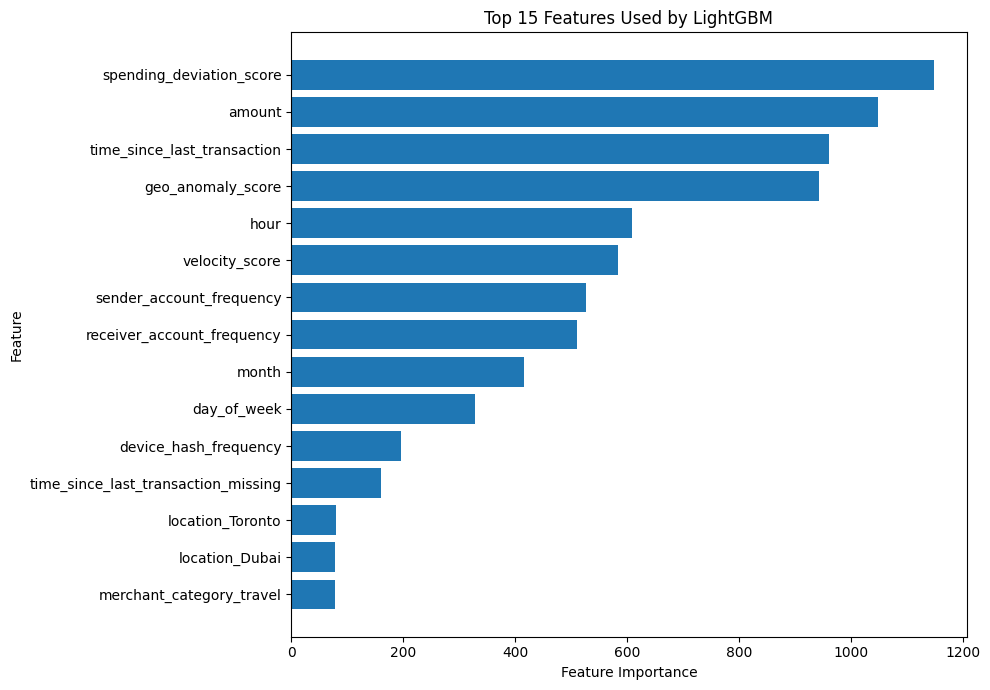

In [14]:
# Step 44: Plot top 15 LightGBM feature importance

import matplotlib.pyplot as plt

top_features = feature_importance.head(15).sort_values(
    by="Importance"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Features Used by LightGBM")

plt.tight_layout()
plt.show()

In [16]:
# Step 45: Recreate model comparison table

model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "LightGBM"
    ],
    "Accuracy": [
        0.2890,
        accuracy_score(y_test, lgbm_pred)
    ],
    "Precision": [
        0.0437,
        precision_score(y_test, lgbm_pred)
    ],
    "Recall": [
        0.9009,
        recall_score(y_test, lgbm_pred)
    ],
    "F1 Score": [
        0.0834,
        f1_score(y_test, lgbm_pred)
    ],
    "ROC-AUC": [
        0.5925,
        roc_auc_score(y_test, lgbm_prob)
    ],
    "PR-AUC": [
        0.0438,
        average_precision_score(y_test, lgbm_prob)
    ]
})

model_comparison = model_comparison.round(4)

print("Model Comparison")
print("================")
print(model_comparison.to_string(index=False))

Model Comparison
              Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC  PR-AUC
Logistic Regression    0.2890     0.0437  0.9009    0.0834   0.5925  0.0438
           LightGBM    0.2315     0.0438  0.9782    0.0838   0.5943  0.0441
